In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [5]:
df = pd.read_csv("Documents/Project/nigeria_houses_data.csv")
print(df.shape)
df.info()

(24326, 8)
<class 'pandas.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  float64
 1   bathrooms      24326 non-null  float64
 2   toilets        24326 non-null  float64
 3   parking_space  24326 non-null  float64
 4   title          24326 non-null  str    
 5   town           24326 non-null  str    
 6   state          24326 non-null  str    
 7   price          24326 non-null  float64
dtypes: float64(5), str(3)
memory usage: 1.5 MB


In [28]:
df.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0


In [19]:
print(df["state"].value_counts().to_string())
print(df["title"].value_counts().to_string())
print(df["town"].value_counts().to_string())

state
Lagos          18445
Abuja           3524
Ogun             637
Oyo              477
Rivers           444
Imo              246
Anambara         145
Enugu            128
Edo              100
Delta             63
Akwa Ibom         25
Kaduna            23
Osun              12
Kwara              9
Nasarawa           9
Abia               9
Ekiti              9
Kogi               8
Cross River        2
Plateau            2
Kano               2
Katsina            2
Bayelsa            2
Borno              2
Niger              1
title
Detached Duplex           13992
Terraced Duplexes          3237
Semi Detached Duplex       2615
Detached Bungalow          2108
Block of Flats             1745
Semi Detached Bungalow      452
Terraced Bungalow           177
town
Lekki                        10895
Ajah                          2164
Ikoyi                         1547
Ikeja                          688
Ibeju Lekki                    503
Victoria Island (VI)           496
Port Harcourt           

In [21]:
df.isnull().sum()
df.isnull().sum() / len(df) * 100  # as percentages

bedrooms         0.0
bathrooms        0.0
toilets          0.0
parking_space    0.0
title            0.0
town             0.0
state            0.0
price            0.0
dtype: float64

In [25]:
print(f"Length of df:{len(df)}")
print(f"Sum of duplicates:{df.duplicated().sum()}")
print(f"Percentage of duplicates:{df.duplicated().sum()/len(df)*100}")

Length of df:24326
Sum of duplicates:10438
Percentage of duplicates:42.90882183671791


In [27]:
df=df.drop_duplicates()
print(f"length of df after dropping duplicates:{len(df)}")

length of df after dropping duplicates:13888


## Handling Duplicates.
The raw dataset contained 10438 duplicates(42%).This was likely caused by repeated scraping of multiple house listings. They were removed leaving 13888 unique records.

In [53]:
df["price"].describe()

count    1.388800e+04
mean     4.002137e+08
std      1.614926e+10
min      9.000000e+04
25%      3.800000e+07
50%      7.500000e+07
75%      1.600000e+08
max      1.800000e+12
Name: price, dtype: float64

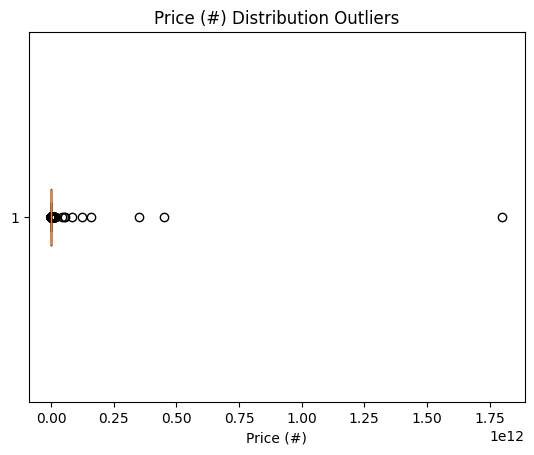

In [52]:
fig, ax = plt.subplots()
plt.boxplot(x=df["price"], vert = False)
ax.set_title("Price (#) Distribution Outliers")
ax.set_xlabel("Price (#)");


In [47]:
df_clean=df[(df["price"]>=df["price"].quantile(0.01))&
              (df["price"]<=df["price"].quantile(0.99))]
print(f"Rows before cleaning: {len(df)} ")
print(f"Rows before cleaning: {len(df_clean)}")

Rows before cleaning: 13888 
Rows before cleaning: 13631


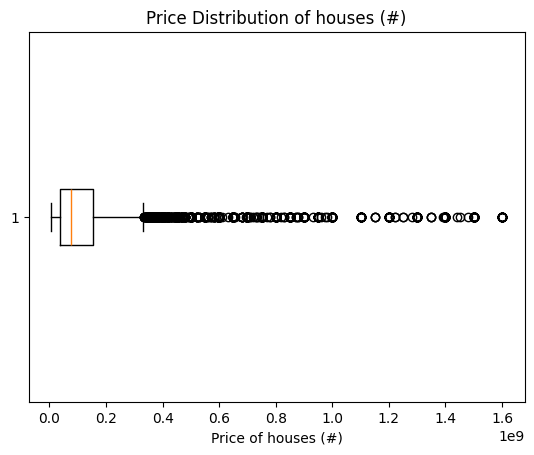

In [51]:
fig,ax = plt.subplots()
plt.boxplot(x= df_clean["price"], vert= False)
ax.set_title("Price Distribution of houses (#)")
ax.set_xlabel("Price of houses (#)");

## Outlier Detection & Removal

Outliers were checked in the `price` column since it is the target variable and most likely to contain extreme values.

A boxplot of the raw data revealed extreme outliers reaching up to ₦1.8 trillion, causing the entire distribution to be unreadable. These were almost certainly data entry errors or scraping artifacts.

To handle this, prices below the 1st percentile and above the 99th percentile were removed using a quantile filter. This brought the dataset from 13,888 rows down to 13,631 rows ,a loss of 257 records (2%).

The cleaned boxplot shows a median price of approximately ₦35M, with most properties falling between ₦20M and ₦90M. The distribution remains right-skewed, which is expected for real estate data with a large number of affordable properties with a long tail of luxury listings.


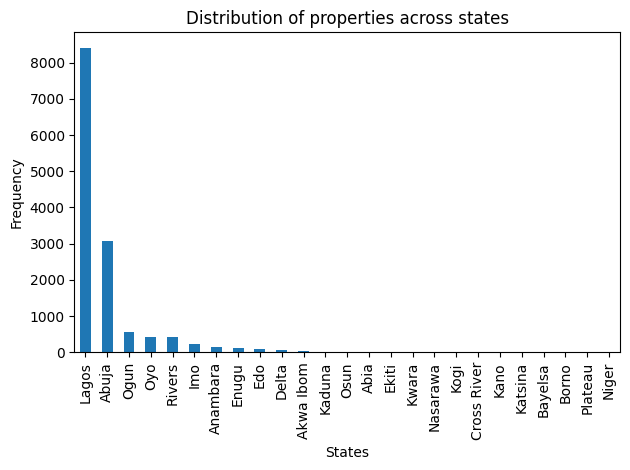

In [58]:
fig, ax= plt.subplots()
df_clean["state"].value_counts().plot(kind= "bar", ax=ax)
ax.set_title("Distribution of properties across states")
ax.set_xlabel("States")
ax.set_ylabel("Frequency")
plt.tight_layout();

## Distribution of properties across states.
The dataset is heavily concentrated in Lagos and Abuja, together accounting for most of the  listings. Most other states have fewer than 500 records, which may limit the model's predictive accuracy for those regions. 

In [60]:
df_clean["title"].value_counts()

title
Detached Duplex           6335
Terraced Duplexes         1979
Detached Bungalow         1816
Block of Flats            1500
Semi Detached Duplex      1416
Semi Detached Bungalow     413
Terraced Bungalow          172
Name: count, dtype: int64

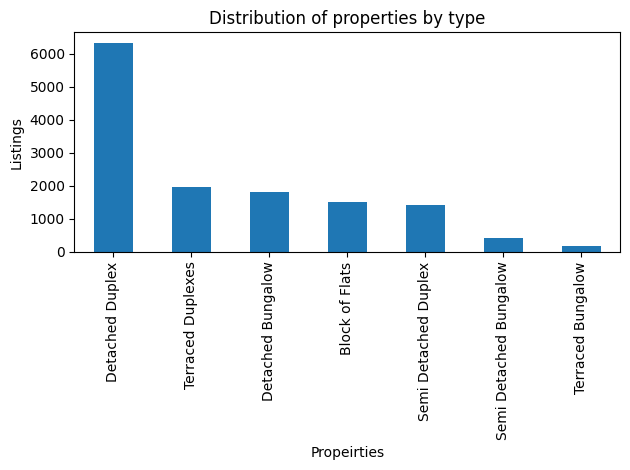

In [59]:
fig, ax= plt.subplots()
df_clean["title"].value_counts().plot(kind= "bar", ax=ax)
ax.set_title("Distribution of properties by type")
ax.set_xlabel("Propeirties")
ax.set_ylabel("Listings")
plt.tight_layout();

##  Property type listings
Detached duplexes have the most listings in the dataset, accounting for  over 6,335 listings, while other property types trail behind from less than 2000 listings  to 172 listings which is the Terraced Bungalow.

In [64]:
df_clean.groupby("state")["price"].mean().sort_values(ascending=False)

state
Abuja          1.831264e+08
Lagos          1.604962e+08
Delta          1.057541e+08
Borno          1.050000e+08
Anambara       9.552934e+07
Abia           9.222222e+07
Bayelsa        9.000000e+07
Rivers         8.611974e+07
Imo            7.444583e+07
Enugu          6.719292e+07
Ekiti          5.488889e+07
Edo            5.120833e+07
Akwa Ibom      4.630000e+07
Oyo            4.557122e+07
Niger          4.000000e+07
Nasarawa       3.975000e+07
Osun           3.690000e+07
Kaduna         3.477273e+07
Kano           3.000000e+07
Kogi           2.725000e+07
Plateau        2.700000e+07
Ogun           2.521928e+07
Cross River    2.500000e+07
Kwara          2.487500e+07
Katsina        1.050000e+07
Name: price, dtype: float64

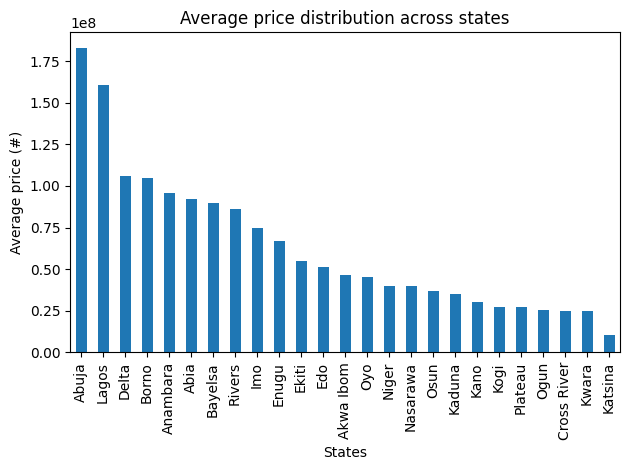

In [62]:
fig, ax = plt.subplots()
df_clean.groupby("state")["price"].mean().sort_values(ascending = False).plot(kind = "bar", ax= ax)
ax.set_title("Average price distribution across states")
ax.set_xlabel("States")
ax.set_ylabel("Average price (#)")
plt.tight_layout();

### 
Despite Lagos having the highest number of listings, Abuja has the highest 
average property price. This suggests Abuja's market skews towards premium 
properties, likely driven by demand from government officials, diplomats, 
and corporate executives. Lagos, while more active, has a wider price range 
that pulls its average down.

In [7]:
def format_naira(price):
    return (f"#{price:,.0f}")


In [8]:
df. groupby("state")["price"].mean().sort_values(ascending=False).apply(format_naira)

state
Lagos          #345,772,144
Abuja          #227,924,611
Rivers         #130,328,410
Borno          #105,000,000
Delta          #103,023,810
Anambara        #94,652,666
Abia            #92,222,222
Bayelsa         #90,000,000
Imo             #74,725,610
Enugu           #66,559,766
Ekiti           #54,888,889
Edo             #49,970,000
Akwa Ibom       #46,300,000
Oyo             #43,113,417
Niger           #40,000,000
Osun            #36,900,000
Nasarawa        #35,666,667
Kaduna          #33,478,261
Kano            #30,000,000
Kogi            #27,250,000
Cross River     #25,000,000
Ogun            #23,281,684
Kwara           #22,666,667
Plateau         #13,750,000
Katsina         #10,500,000
Name: price, dtype: str

In [9]:
df.groupby("title")["price"].mean().sort_values(ascending=False).apply(format_naira)

title
Detached Duplex           #400,303,590
Semi Detached Duplex      #349,884,549
Block of Flats            #175,738,604
Terraced Duplexes         #121,975,509
Terraced Bungalow          #44,481,699
Detached Bungalow          #42,633,332
Semi Detached Bungalow     #35,699,360
Name: price, dtype: str

In [12]:
print(df["price"].quantile([0.01,0.25,0.50,0.75,0.99]))

0.01    7.200000e+06
0.25    5.200000e+07
0.50    8.500000e+07
0.75    1.600000e+08
0.99    1.400000e+09
Name: price, dtype: float64
